# Prostate158 — Anatomy Segmentation Evaluation

Evaluates predictions from the MONAI `prostate_mri_anatomy` bundle against
Prostate158 ground-truth anatomy labels (`t2_anatomy_reader1.nii.gz`).

**Labels**
| Value | Structure |
|-------|-----------|
| 1     | Central gland (CG) |
| 2     | Peripheral zone (PZ) |
| 1+2   | Whole gland (WG) |

In [1]:
%config InlineBackend.figure_formats = ['jpeg']

import sys
sys.path.insert(0, "../src")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from prostate158_cases import build_prostate158_anatomy_cases
from seg_metrics import compute_segmentation_metrics

## Configuration
Swap `CSV_PATH` to `valid.csv` to evaluate the validation split.

In [2]:
DATASET_DIR = Path("../data/raw/zenodo/prostate158/record-6481141/prostate158_train")
RESULTS_DIR = Path("../results/anatomy") # Generated from https://huggingface.co/MONAI/prostate_mri_anatomy/commit/2bfceed082de08e9f2b36a50662c99b6243ee794
CSV_PATH    = DATASET_DIR / "valid.csv"   # change to test.csv/valid.csv

LABELS = {1: "CG", 2: "PZ"}

cases = build_prostate158_anatomy_cases(CSV_PATH, DATASET_DIR, RESULTS_DIR)

for c in cases:
    for field in ("image_path", "gt_path", "pred_path"):
        assert field in c, f"Missing field '{field}' in case: {c}"
        assert Path(c[field]).exists(), f"Missing file for case {c.get('case_id', 'unknown')}: {c[field]}"

print(f"{len(cases)} cases loaded from {CSV_PATH.name}")
pd.DataFrame(cases)

20 cases loaded from valid.csv


,case_id,image_path,gt_path,pred_path
0,20,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/020/t2/t2_trans.nii.gz
1,21,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/021/t2/t2_trans.nii.gz
2,22,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/022/t2/t2_trans.nii.gz
3,23,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/023/t2/t2_trans.nii.gz
4,38,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/038/t2/t2_trans.nii.gz
5,41,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/041/t2/t2_trans.nii.gz
6,46,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/046/t2/t2_trans.nii.gz
7,47,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/047/t2/t2_trans.nii.gz
8,51,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/051/t2/t2_trans.nii.gz
9,56,../data/raw/zenodo/prostate158/record-6481141/...,../data/raw/zenodo/prostate158/record-6481141/...,../results/anatomy/train/056/t2/t2_trans.nii.gz


## Compute metrics per case and label

In [3]:
rows = []

for case in tqdm(cases):
    gt_img   = nib.load(case["gt_path"])
    pred_img = nib.load(case["pred_path"])

    gt_arr   = np.asarray(gt_img.dataobj).astype(np.int16)
    pred_arr = np.asarray(pred_img.dataobj).astype(np.int16)
    spacing  = tuple(float(v) for v in gt_img.header.get_zooms()[:3])

    label_masks = dict(LABELS)
    label_masks["WG"] = None  # whole gland handled below

    for label_val, label_name in LABELS.items():
        gt_bin   = gt_arr == label_val
        pred_bin = pred_arr == label_val
        m = compute_segmentation_metrics(pred_bin, gt_bin, spacing)
        m["abs_vol_err_mm3"] = abs(m["pred_vol_mm3"] - m["gt_vol_mm3"])
        rows.append({"case_id": case["case_id"], "label": label_name, **m})

    # Whole gland = union of CG + PZ
    gt_wg   = gt_arr > 0
    pred_wg = pred_arr > 0
    m = compute_segmentation_metrics(pred_wg, gt_wg, spacing)
    m["abs_vol_err_mm3"] = abs(m["pred_vol_mm3"] - m["gt_vol_mm3"])
    rows.append({"case_id": case["case_id"], "label": "WG", **m})

df = pd.DataFrame(rows)
print(f"Metrics computed for {df['case_id'].nunique()} cases × {df['label'].nunique()} labels")

  0%|          | 0/20 [00:00<?, ?it/s]

Metrics computed for 20 cases × 3 labels


## Summary table

In [4]:
metric_cols = ["dsc", "iou", "hd95_mm", "assd_mm",
               "pred_vol_mm3", "gt_vol_mm3", "abs_vol_err_mm3"]

summary = (
    df.groupby("label")[metric_cols]
    .agg(["mean", "std"])
    .round(3)
)
# Flatten multi-level columns for readability
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]
summary = summary.loc[["CG", "PZ", "WG"]]  # consistent row order
summary

,dsc_mean,dsc_std,iou_mean,iou_std,hd95_mm_mean,hd95_mm_std,assd_mm_mean,assd_mm_std,pred_vol_mm3_mean,pred_vol_mm3_std,gt_vol_mm3_mean,gt_vol_mm3_std,abs_vol_err_mm3_mean,abs_vol_err_mm3_std
label,,,,,,,,,,,,,,
CG,0.864,0.040,0.763,0.062,4.737,1.765,1.243,0.342,32440.886,14271.379,32212.583,14677.322,2193.419,2188.913
PZ,0.749,0.085,0.605,0.096,3.856,2.522,0.889,0.454,12289.484,3629.581,13938.245,5562.127,2468.969,1882.112
WG,0.900,0.024,0.820,0.040,3.441,0.912,0.957,0.242,44730.370,14672.776,46150.828,15356.272,2725.882,2230.570


## Bland-Altman volume plots

X axis = ground-truth volume; Y axis = prediction − GT.  
Left column: absolute difference (mm³). Right column: proportional difference (fraction of GT).  
Dashed lines show mean bias ± 1.96 SD.

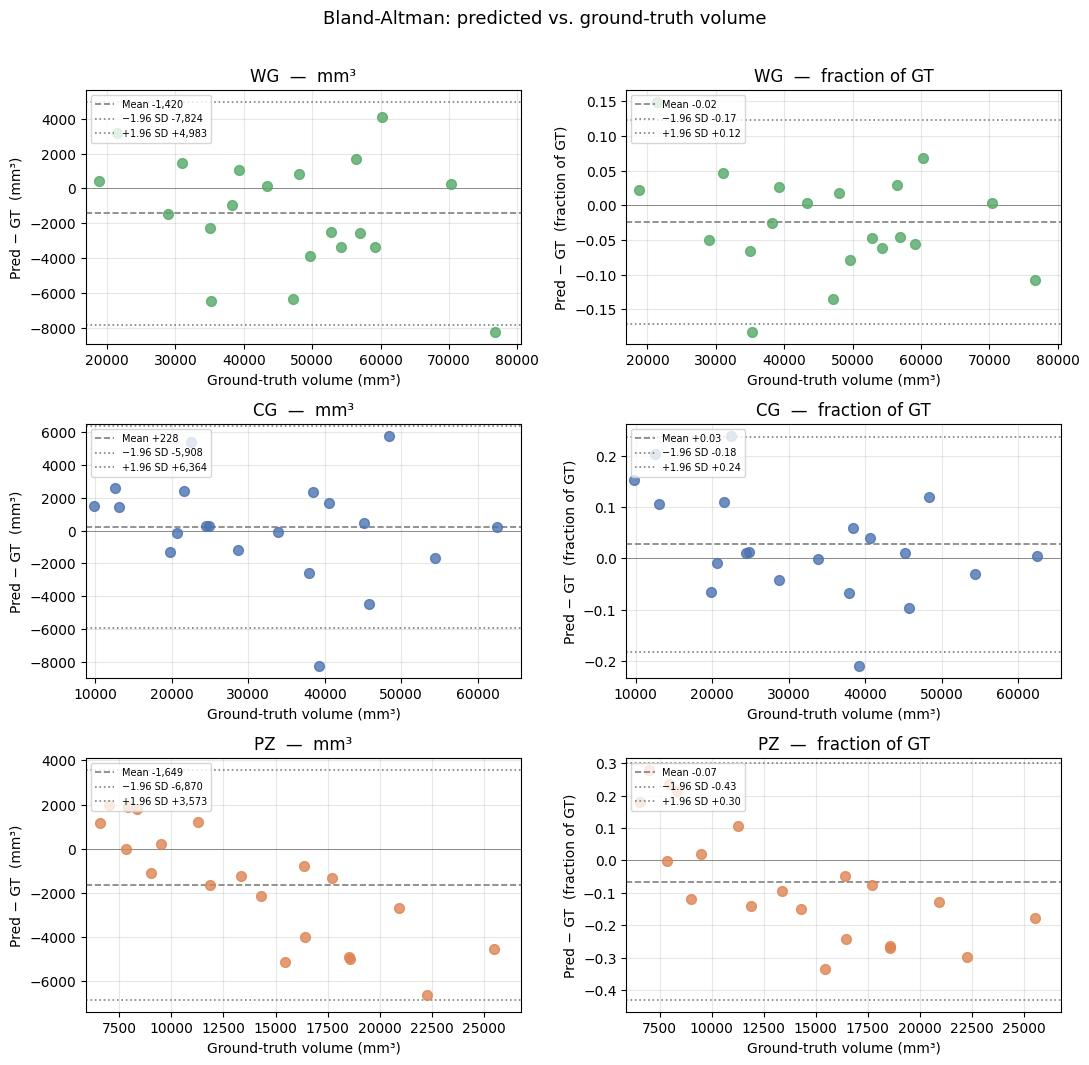

In [5]:
label_order  = ["WG", "CG", "PZ"]
label_colors = {"WG": "#55A868", "CG": "#4C72B0", "PZ": "#DD8452"}

fig, axes = plt.subplots(len(label_order), 2, figsize=(11, 3.5 * len(label_order)))
fig.suptitle("Bland-Altman: predicted vs. ground-truth volume", fontsize=13, y=1.01)

for row, lbl in enumerate(label_order):
    sub = df[df["label"] == lbl].copy()
    sub["diff_abs"]  = sub["pred_vol_mm3"] - sub["gt_vol_mm3"]          # mm³
    sub["diff_prop"] = sub["diff_abs"] / sub["gt_vol_mm3"]               # fraction of GT

    color = label_colors[lbl]

    for col, (y_col, y_label, fmt) in enumerate([
        ("diff_abs",  "Pred − GT  (mm³)",          lambda v: f"{v:+,.0f}"),
        ("diff_prop", "Pred − GT  (fraction of GT)", lambda v: f"{v:+.2f}"),
    ]):
        ax = axes[row, col]
        ax.scatter(sub["gt_vol_mm3"], sub[y_col], color=color, alpha=0.8, s=50, zorder=3)

        mean  = sub[y_col].mean()
        sd    = sub[y_col].std()
        lo, hi = mean - 1.96 * sd, mean + 1.96 * sd
        xlim = ax.get_xlim()
        x_range = [sub["gt_vol_mm3"].min() * 0.9, sub["gt_vol_mm3"].max() * 1.05]

        for val, ls, label_txt in [
            (mean, "--", f"Mean {fmt(mean)}"),
            (lo,   ":",  f"−1.96 SD {fmt(lo)}"),
            (hi,   ":",  f"+1.96 SD {fmt(hi)}"),
        ]:
            ax.axhline(val, linestyle=ls, color="gray", linewidth=1.2, label=label_txt)

        ax.axhline(0, color="black", linewidth=0.7, alpha=0.4)
        ax.set_xlim(x_range)
        ax.set_xlabel("Ground-truth volume (mm³)")
        ax.set_ylabel(y_label)
        ax.set_title(f"{lbl}  —  {y_label.split('(')[1].rstrip(')')}")
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Per-case DSC distribution

/tmp/ipykernel_456000/4155848799.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dsc_data, labels=label_order, patch_artist=True, notch=False)


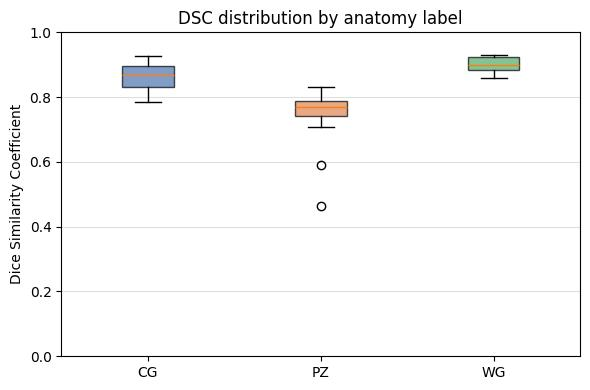

In [6]:
label_order = ["CG", "PZ", "WG"]
dsc_data = [df.loc[df["label"] == lbl, "dsc"].values for lbl in label_order]

fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(dsc_data, labels=label_order, patch_artist=True, notch=False)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Dice Similarity Coefficient")
ax.set_title("DSC distribution by anatomy label")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Best and worst cases (by whole-gland DSC)

In [7]:
wg_dsc = df[df["label"] == "WG"][["case_id", "dsc"]].sort_values("dsc", ascending=False)

best5  = wg_dsc.head(5)
worst5 = wg_dsc.tail(5)

print("Top-5 (highest WG DSC):")
print(best5.to_string(index=False))
print("\nBottom-5 (lowest WG DSC):")
print(worst5.to_string(index=False))

Top-5 (highest WG DSC):
 case_id      dsc
      61 0.931280
      22 0.930586
      87 0.924878
     114 0.924149
      21 0.923602

Bottom-5 (lowest WG DSC):
 case_id      dsc
     118 0.881359
     109 0.880901
      56 0.863084
      23 0.858936
      77 0.857795


## Qualitative visualisation

In [8]:
LABEL_COLORS = {1: "#4C72B0", 2: "#DD8452"}  # CG=blue, PZ=orange

def show_case(case_dict: dict, n_slices: int = 9) -> None:
    """Show T2 image alongside GT and prediction overlays for a single case.

    Each label is drawn in a distinct color (CG=blue, PZ=orange) for both GT and Pred rows.
    """
    img_arr  = np.asarray(nib.load(case_dict["image_path"]).dataobj)
    gt_arr   = np.asarray(nib.load(case_dict["gt_path"]).dataobj).astype(np.int16)
    pred_arr = np.asarray(nib.load(case_dict["pred_path"]).dataobj).astype(np.int16)

    # Find axial extent of the ground-truth gland
    gland_slices = np.where((gt_arr > 0).any(axis=(0, 1)))[0]
    if len(gland_slices) == 0:
        print(f"Case {case_dict['case_id']}: no GT voxels, skipping")
        return

    slice_indices = np.linspace(gland_slices[0], gland_slices[-1], n_slices, dtype=int)

    def _row(label: str) -> pd.Series:
        return df.loc[(df.case_id == case_dict["case_id"]) & (df.label == label)].iloc[0]

    cg, pz, wg = _row("CG"), _row("PZ"), _row("WG")

    title = (
        f"Case {case_dict['case_id']}  —  "
        f"DSC: WG={wg['dsc']:.3f}  CG={cg['dsc']:.3f}  PZ={pz['dsc']:.3f}\n"
        f"GT vol (cm³): WG={wg['gt_vol_mm3']/1000:.1f}  CG={cg['gt_vol_mm3']/1000:.1f}  PZ={pz['gt_vol_mm3']/1000:.1f}   "
        f"Pred vol (cm³): WG={wg['pred_vol_mm3']/1000:.1f}  CG={cg['pred_vol_mm3']/1000:.1f}  PZ={pz['pred_vol_mm3']/1000:.1f}"
    )

    fig, axes = plt.subplots(3, n_slices, figsize=(2.2 * n_slices, 7))
    fig.suptitle(title, fontsize=10)

    for col, sl in enumerate(slice_indices):
        t2_slice = img_arr[:, :, sl]
        vmin, vmax = np.percentile(t2_slice[t2_slice > 0], [1, 99]) if t2_slice.any() else (0, 1)

        for row, (seg_arr, row_title) in enumerate([
            (None,      "T2"),
            (gt_arr,    "GT"),
            (pred_arr,  "Pred"),
        ]):
            ax = axes[row, col]
            ax.imshow(t2_slice.T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
            if seg_arr is not None:
                for label_val, color in LABEL_COLORS.items():
                    mask_sl = seg_arr[:, :, sl] == label_val
                    if not mask_sl.any():
                        continue
                    overlay = np.zeros((*t2_slice.shape, 4))
                    overlay[..., :3] = plt.matplotlib.colors.to_rgb(color)
                    overlay[..., 3]  = mask_sl.astype(float) * 0.45
                    ax.imshow(overlay.transpose(1, 0, 2), origin="lower")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(row_title, fontsize=9)

        axes[0, col].set_title(f"z={sl}", fontsize=8)

    plt.tight_layout()
    plt.show()

=== Best 5 cases ===


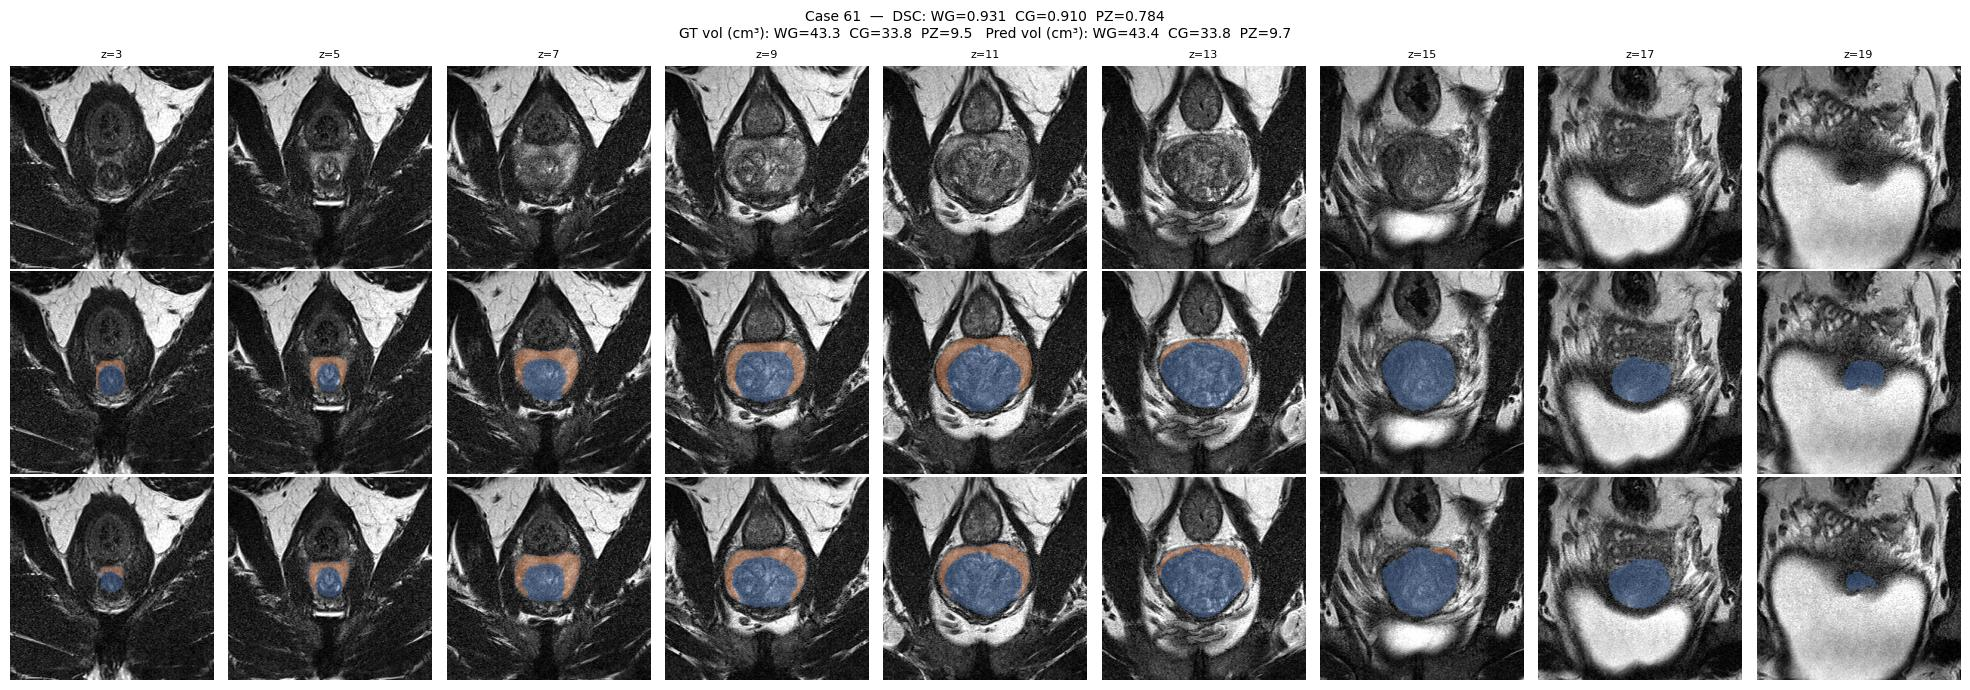

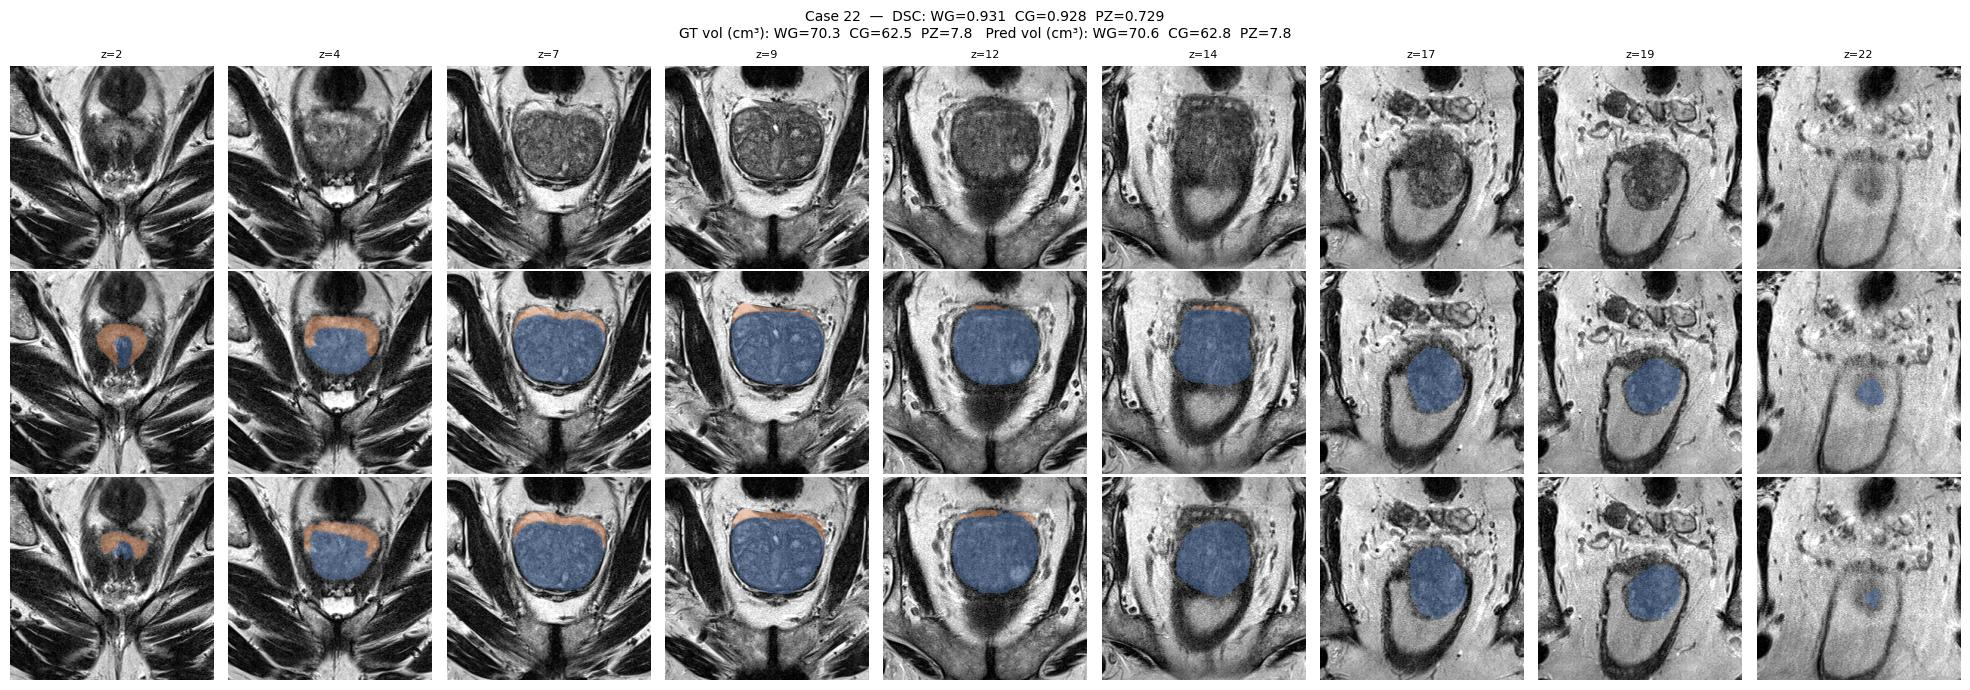

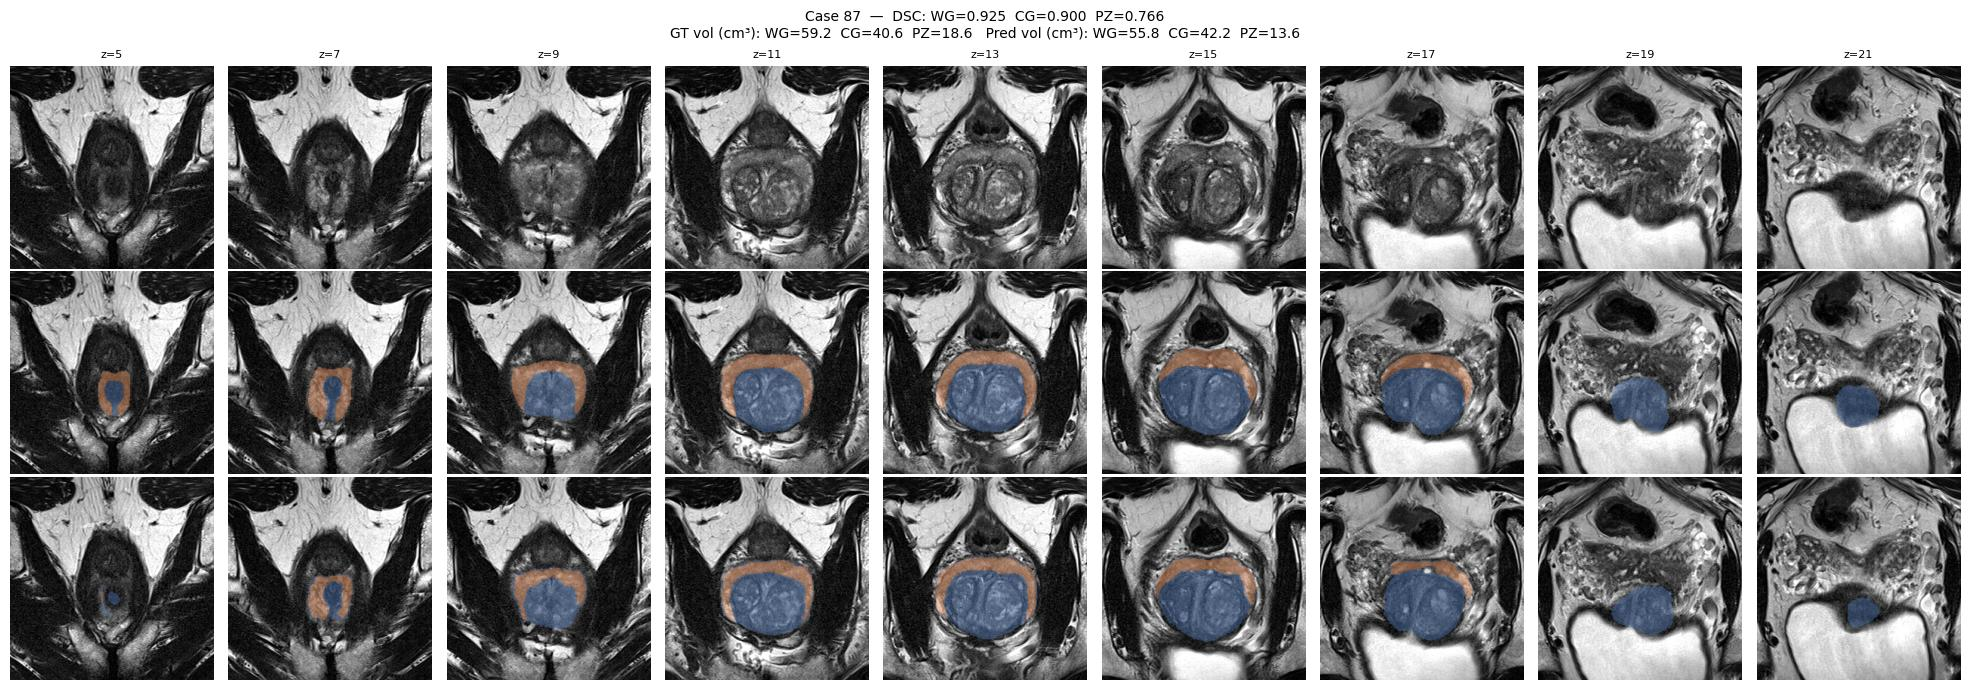

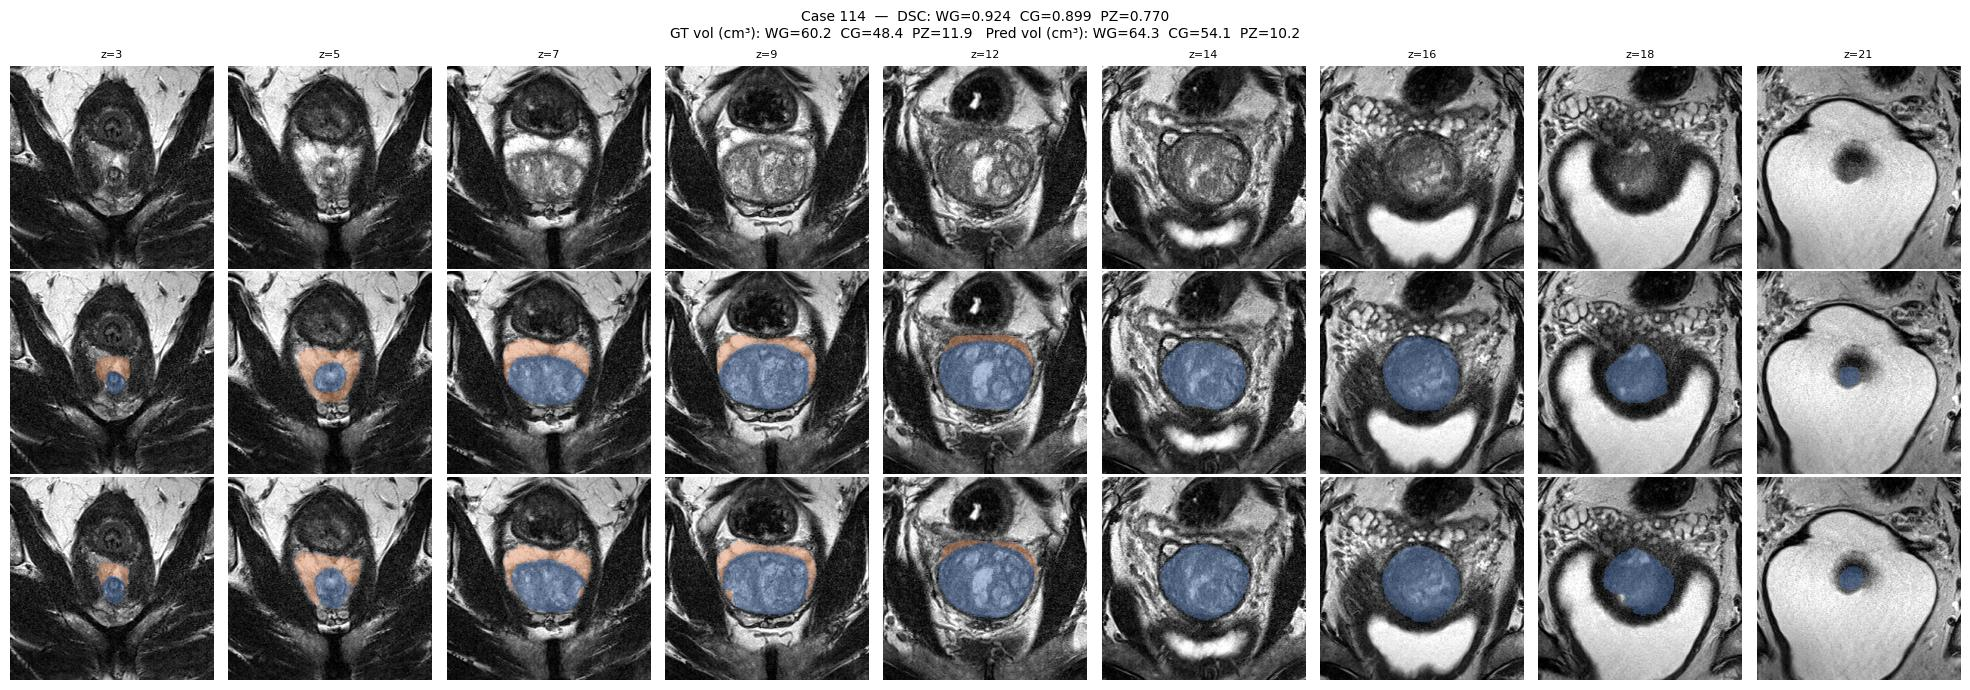

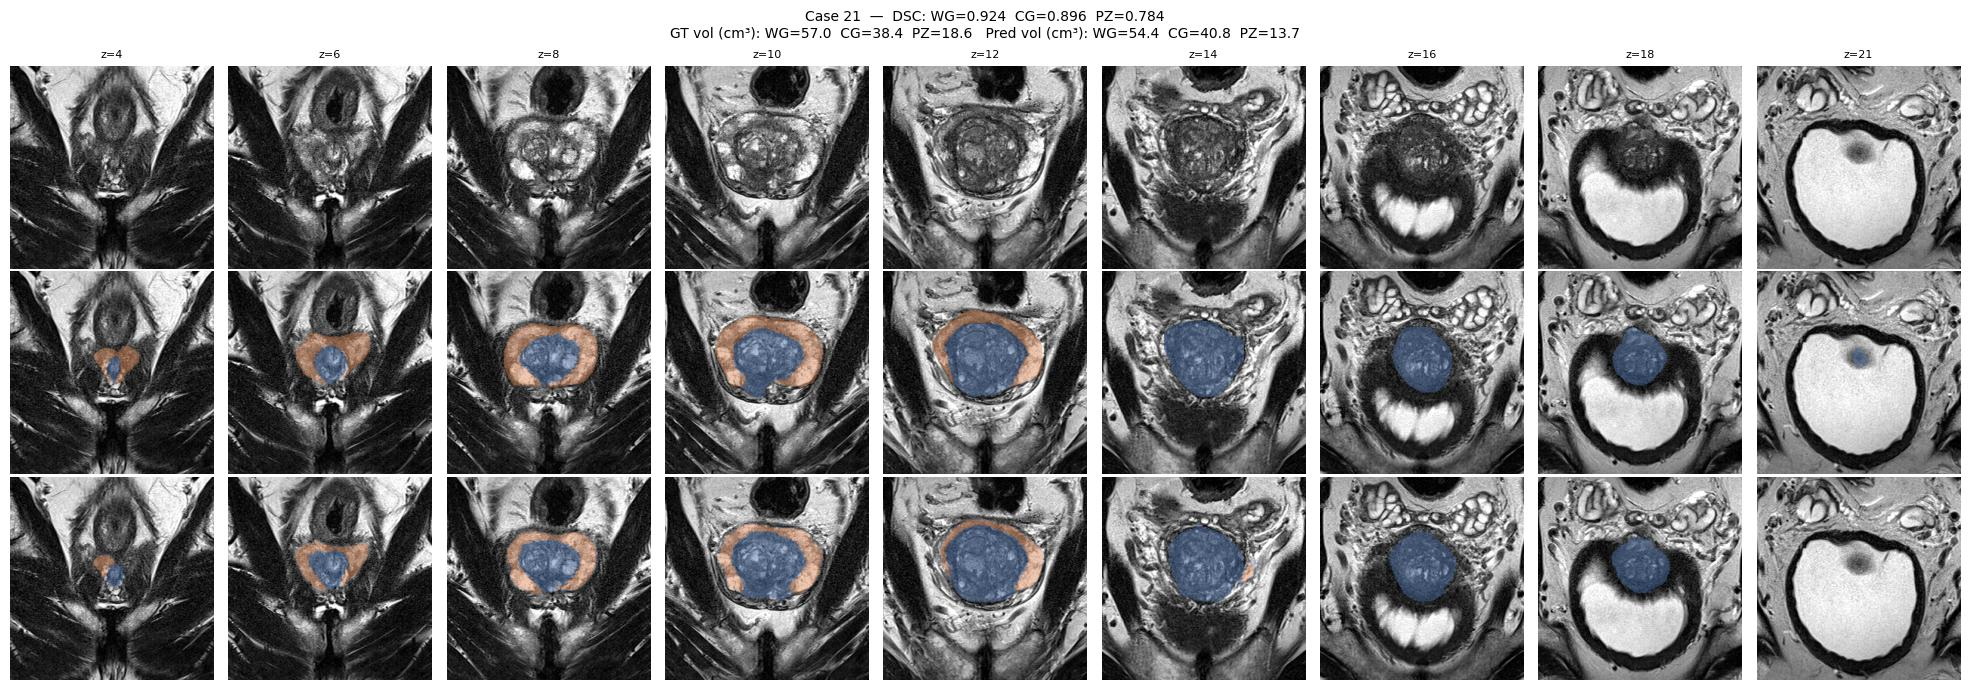

In [9]:
# Build a lookup from case_id to case dict
case_by_id = {c["case_id"]: c for c in cases}

print("=== Best 5 cases ===")
for cid in best5["case_id"]:
    show_case(case_by_id[cid])

=== Worst 5 cases ===


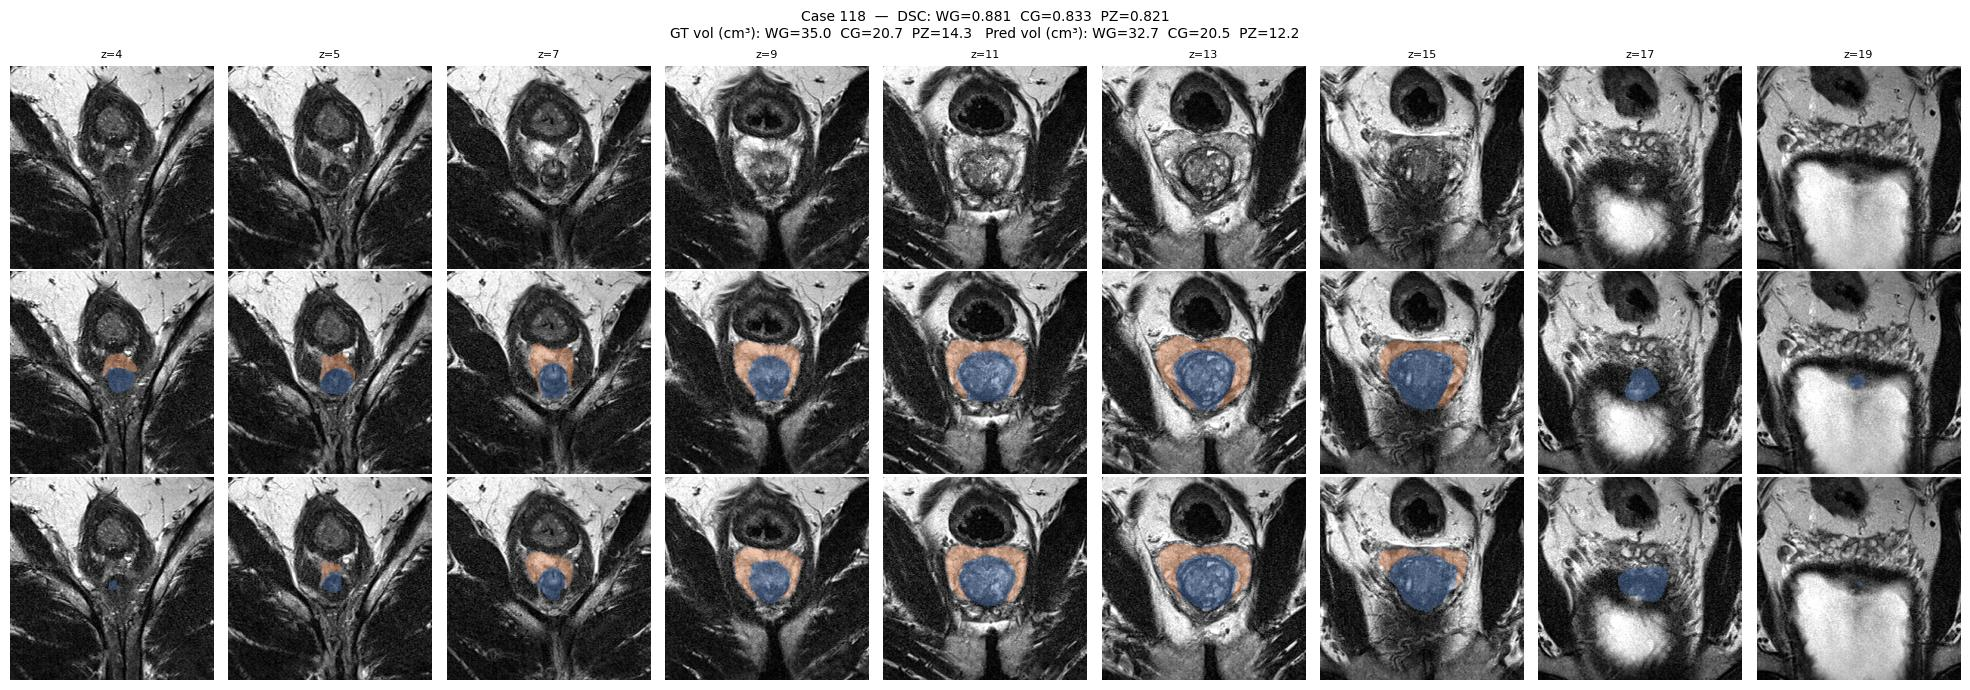

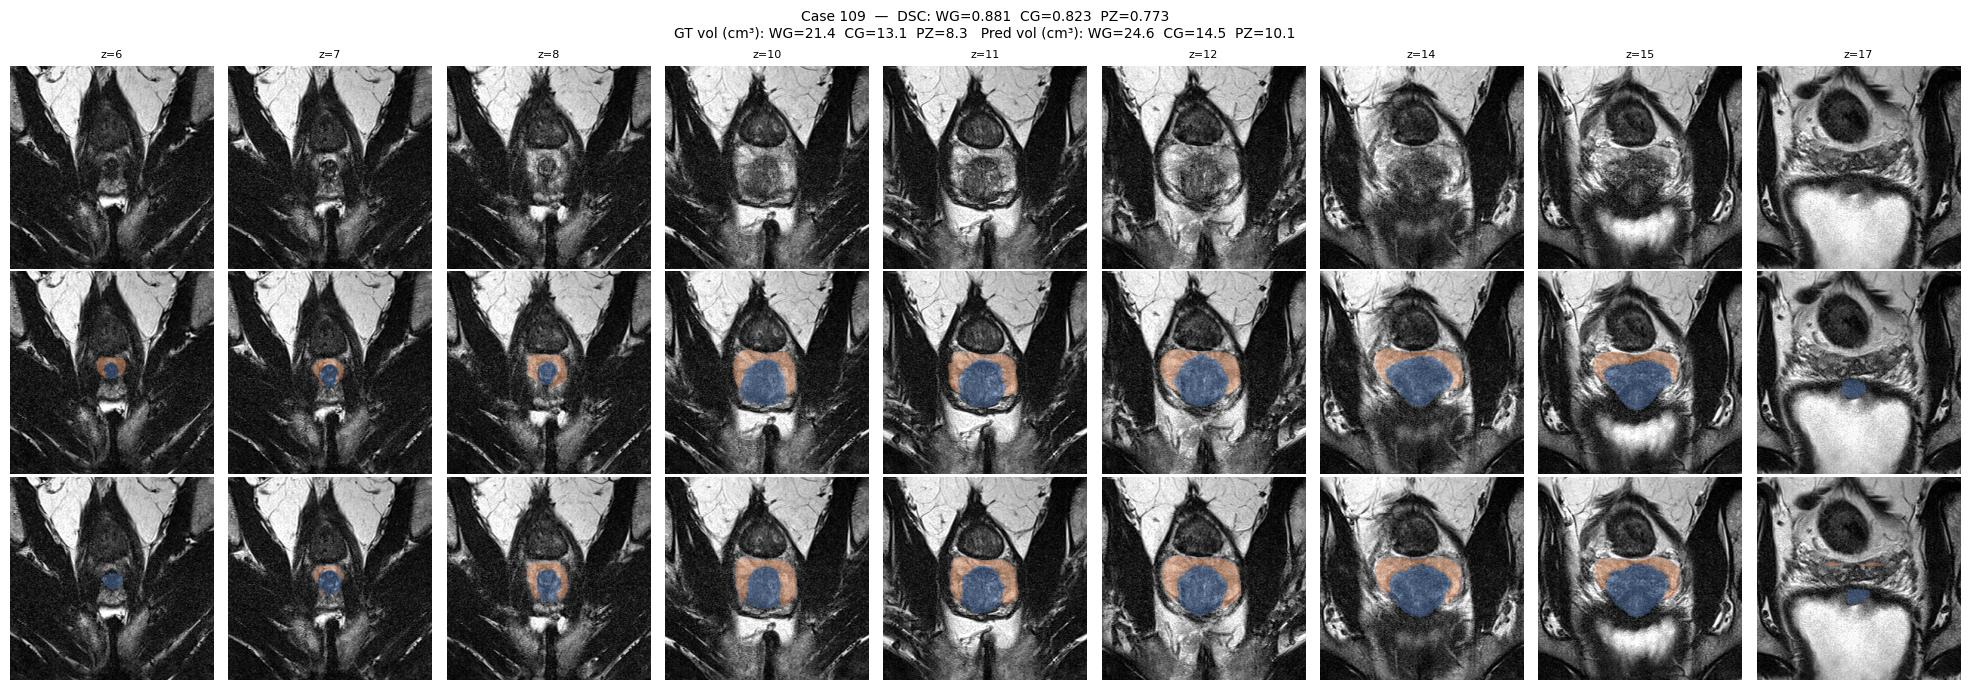

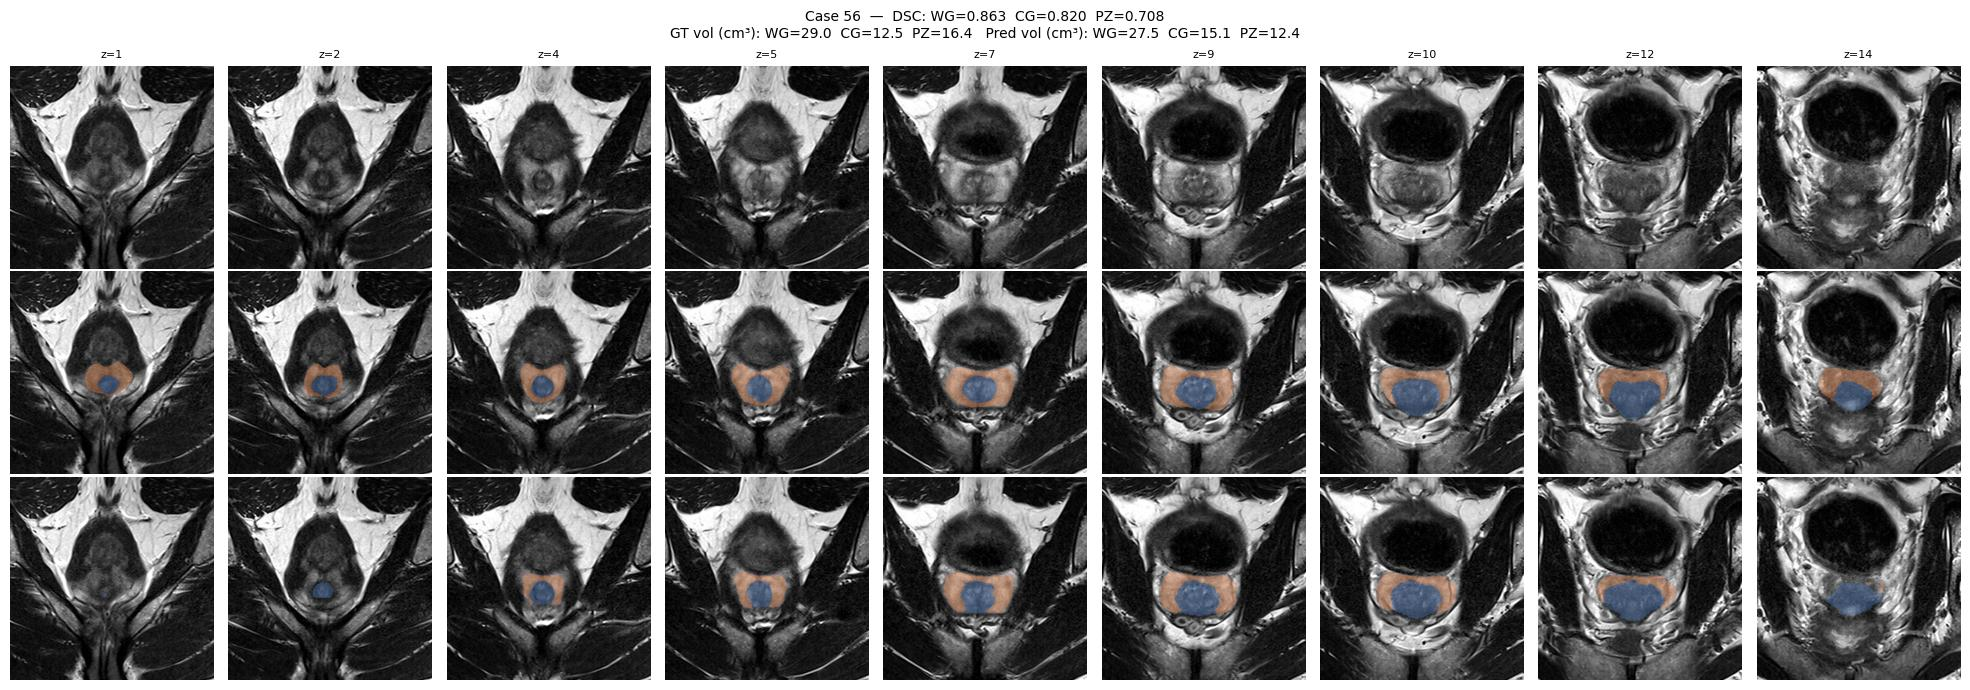

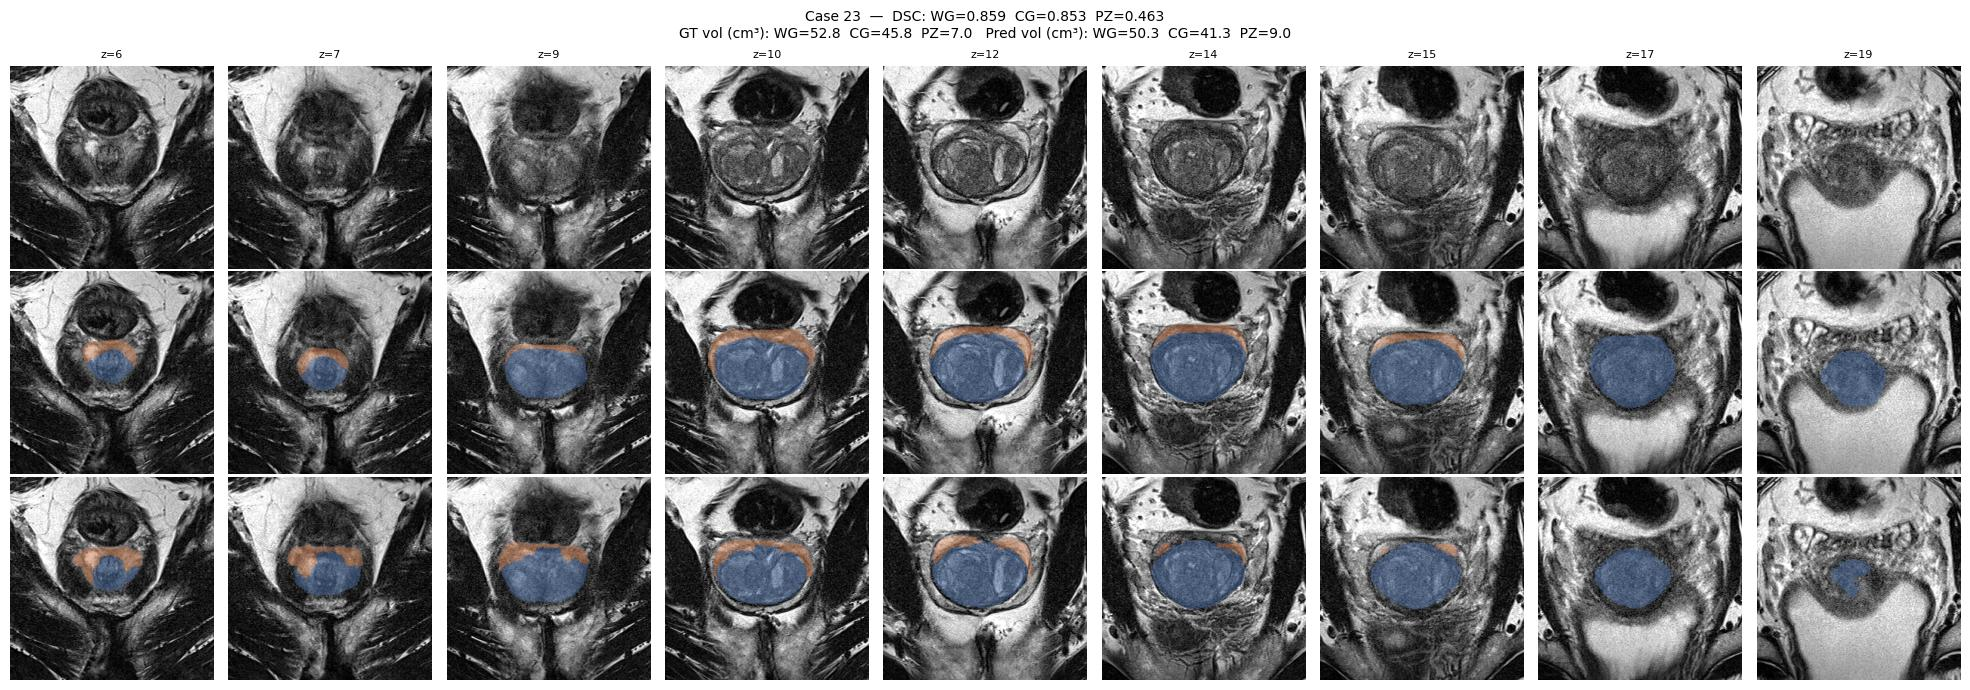

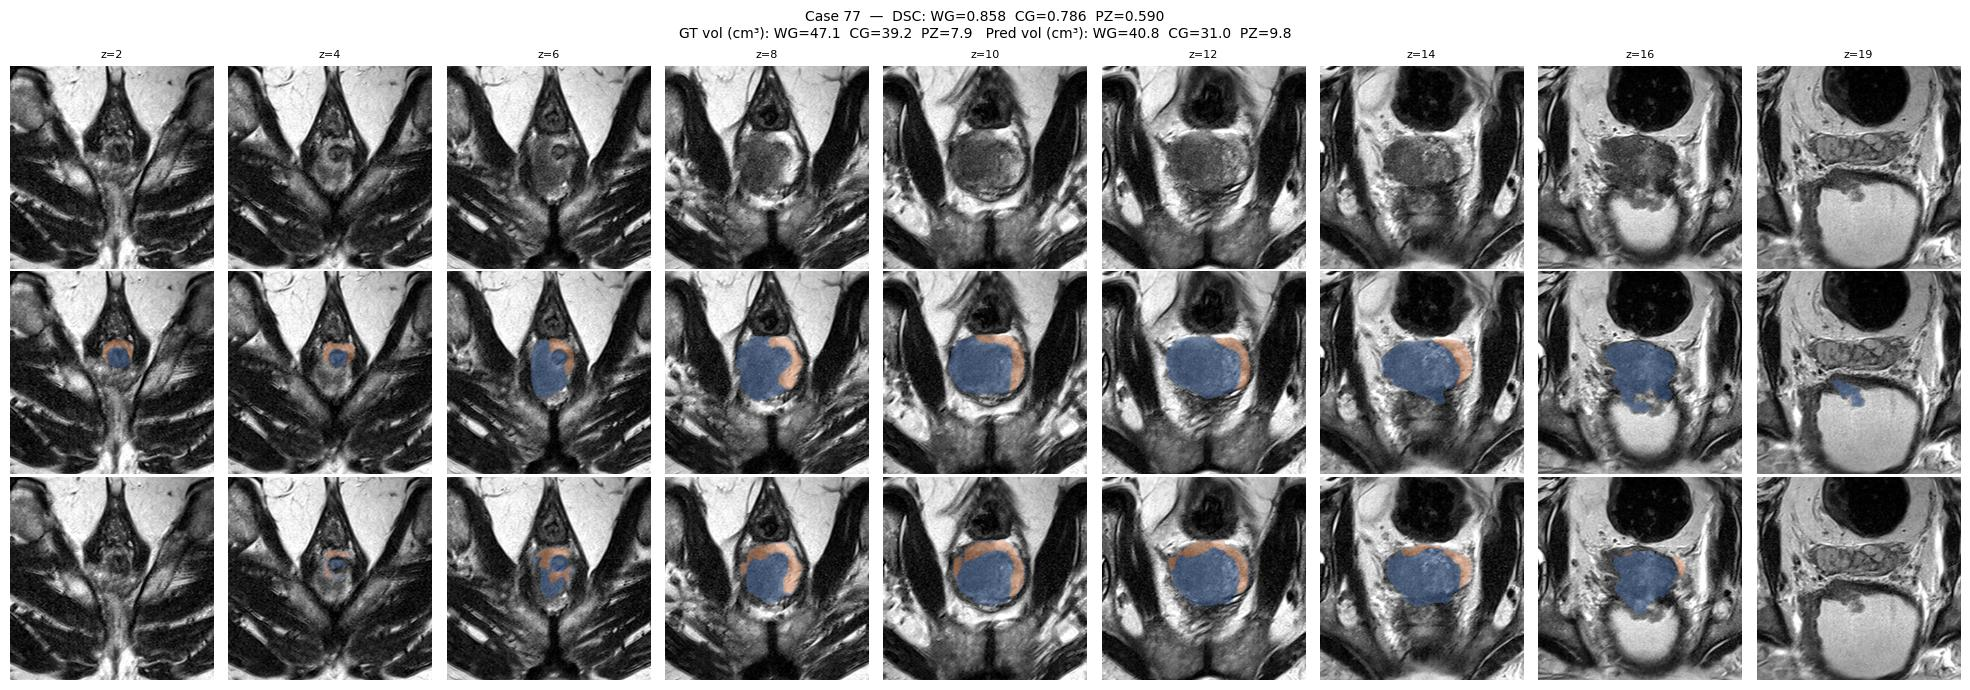

In [10]:
print("=== Worst 5 cases ===")
for cid in worst5["case_id"]:
    show_case(case_by_id[cid])